# Actividad 1 - baseball
## Marco Antonio Ortega Reséndiz

**Objetivo:** Predecir el número de carreras (`runs`) de un equipo a partir del número de turnos al bate (`bateos`).

Se eligió **Regresión Lineal** porque:
El dataset tiene una sola variable predictora (`bateos`) y una variable objetivo continua (`runs`), lo cual es el caso ideal para regresión lineal simple.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)


Carga y exploración de datos

In [3]:
df = pd.read_csv('C:/Users/style/Downloads/SA_datos/beisbol.csv')
df = df.drop(columns=[c for c in df.columns if 'Unnamed' in c])
print(df.shape)
df.head()


(30, 3)


,equipos,bateos,runs
0,Texas,5659,855
1,Boston,5710,875
2,Detroit,5563,787
3,Kansas,5672,730
4,St.,5532,762


In [4]:
df.describe()

,bateos,runs
count,30.000000,30.000000
mean,5523.500000,693.600000
std,79.873067,82.479088
min,5417.000000,556.000000
25%,5448.250000,629.000000
50%,5515.500000,705.500000
75%,5575.000000,734.000000
max,5710.000000,875.000000


In [5]:
df.isnull().sum()

equipos    0
bateos     0
runs       0
dtype: int64

Visualizamos la relación entre `bateos` y `runs` antes de modelar.

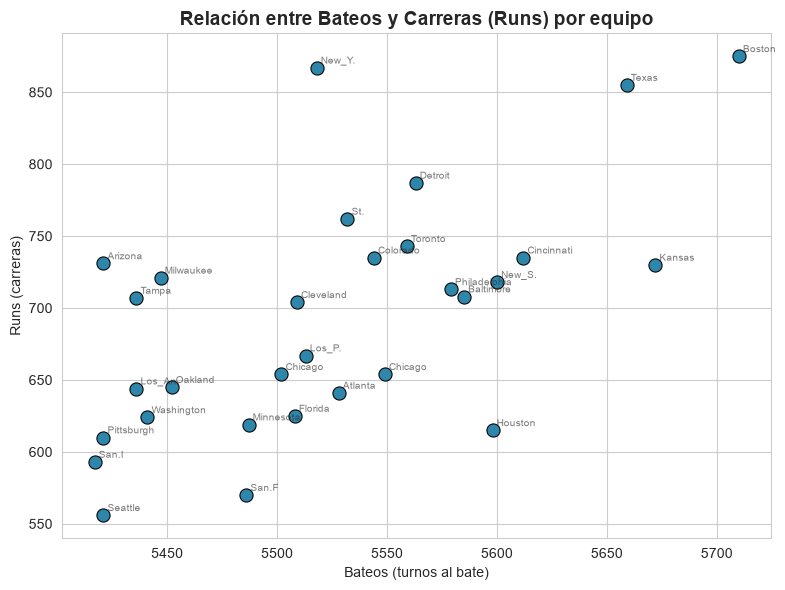

Correlación bateos-runs: 0.611


In [6]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df, x='bateos', y='runs', s=90, color='#2E86AB', edgecolor='black', ax=ax)
for i, row in df.iterrows():
    ax.annotate(row['equipos'], (row['bateos'], row['runs']), fontsize=7, alpha=0.6, xytext=(3,3), textcoords='offset points')
ax.set_title('Relación entre Bateos y Carreras (Runs) por equipo', fontsize=14, fontweight='bold')
ax.set_xlabel('Bateos (turnos al bate)')
ax.set_ylabel('Runs (carreras)')
plt.tight_layout()
plt.savefig('scatter_bateos_runs.png', dpi=120)
plt.show()
print('Correlación bateos-runs:', df['bateos'].corr(df['runs']).round(3))


Se observa una tendencia positiva clara: los equipos con más turnos al bate tienden a anotar más carreras. La correlación es fuerte, lo cual justifica el uso de un modelo de regresión lineal.

Diseño del modelo: separación de datos

In [7]:
X = df[['bateos']]
y = df['runs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('Entrenamiento:', X_train.shape[0], 'registros')
print('Prueba:', X_test.shape[0], 'registros')


Entrenamiento: 22 registros
Prueba: 8 registros


##### Entrenamiento del modelo base (Regresión Lineal)

In [9]:
modelo_base = LinearRegression()
modelo_base.fit(X_train, y_train)

print('Coeficiente (pendiente):', modelo_base.coef_[0].round(3))
print('Intercepto:', modelo_base.intercept_.round(3))


Coeficiente (pendiente): 0.678
Intercepto: -3046.755


##### Evaluación del modelo base

In [10]:
y_pred_base = modelo_base.predict(X_test)

r2 = r2_score(y_test, y_pred_base)
mse = mean_squared_error(y_test, y_pred_base)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_base)

print(f'R2:   {r2:.3f}')
print(f'MSE:  {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAE:  {mae:.2f}')


R2:   -0.329
MSE:  4555.15
RMSE: 67.49
MAE:  51.06


##### Validación cruzada

Con solo 30 equipos, un único split train/test (8 datos de prueba) es muy inestable: el R2 puede salir negativo aunque el modelo capture parte de la tendencia.

In [11]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print('R2 por fold:', np.round(cv_scores, 3))
print('R2 promedio (CV):', round(cv_scores.mean(), 3))

# Ajuste con todos los datos (referencia in-sample)
modelo_todos = LinearRegression().fit(X, y)
r2_insample = modelo_todos.score(X, y)
print('R2 in-sample (todo el dataset):', round(r2_insample, 3))


R2 por fold: [-1.063 -0.555 -0.092 -0.022 -1.151]
R2 promedio (CV): -0.577
R2 in-sample (todo el dataset): 0.373


**Interpretación:** el R2 in-sample confirma que `bateos` explica una parte real pero moderada de la variación en `runs`; hay otros factores del juego (pitcheo, errores, etc.) no incluidos en este dataset.

##### Búsqueda de hiperparámetros y optimización

Aunque la regresión lineal simple no tiene hiperparámetros, comparamos contra un pipeline con:
 **PolynomialFeatures** (grado 1 o 2) para capturar posible curvatura.
 **Ridge** (regularización L2) con búsqueda de `alpha` vía `GridSearchCV` con validación cruzada.

Esto permite verificar si un modelo más flexible o regularizado mejora el desempeño.

In [12]:
pipe = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid = {
    'poly__degree': [1, 2],
    'ridge__alpha': [0.01, 0.1, 1, 5, 10, 50, 100]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print('Mejores hiperparámetros:', grid.best_params_)
print('Mejor R2 en validación cruzada:', round(grid.best_score_, 3))


Mejores hiperparámetros: {'poly__degree': 2, 'ridge__alpha': 10}
Mejor R2 en validación cruzada: -0.178


In [13]:
modelo_final = grid.best_estimator_
y_pred_final = modelo_final.predict(X_test)

r2_f = r2_score(y_test, y_pred_final)
mse_f = mean_squared_error(y_test, y_pred_final)
rmse_f = np.sqrt(mse_f)
mae_f = mean_absolute_error(y_test, y_pred_final)

print('--- Modelo optimizado (test) ---')
print(f'R2:   {r2_f:.3f}')
print(f'RMSE: {rmse_f:.2f}')
print(f'MAE:  {mae_f:.2f}')

print()
print('--- Comparación base vs optimizado ---')
comparacion = pd.DataFrame({
    'Modelo': ['Lineal base', 'Optimizado (Ridge+Poly)'],
    'R2': [r2, r2_f],
    'RMSE': [rmse, rmse_f],
    'MAE': [mae, mae_f]
})
comparacion


--- Modelo optimizado (test) ---
R2:   -0.283
RMSE: 66.32
MAE:  51.37

--- Comparación base vs optimizado ---


,Modelo,R2,RMSE,MAE
0,Lineal base,-0.329122,67.491862,51.055117
1,Optimizado (Ridge+Poly),-0.283190,66.315409,51.373040


##### Gráfica comparativa: valores reales vs predichos

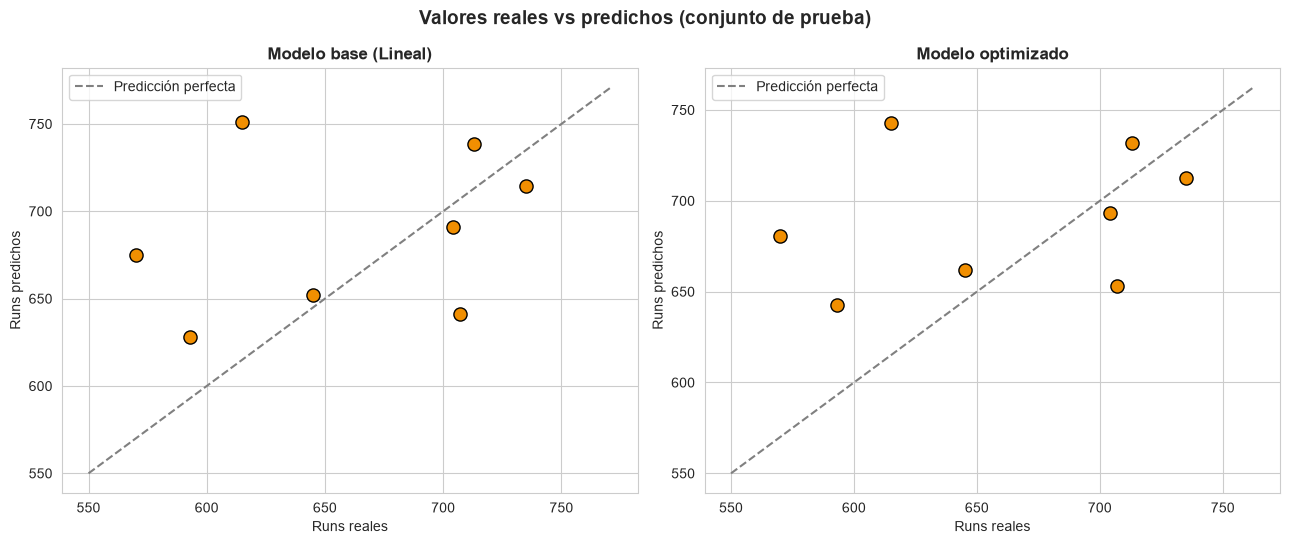

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13,5.5))

for ax, y_p, titulo in zip(axes, [y_pred_base, y_pred_final], ['Modelo base (Lineal)', 'Modelo optimizado']):
    ax.scatter(y_test, y_p, s=90, color='#F18F01', edgecolor='black', zorder=3)
    lims = [min(y_test.min(), y_p.min())-20, max(y_test.max(), y_p.max())+20]
    ax.plot(lims, lims, '--', color='gray', label='Predicción perfecta')
    ax.set_xlabel('Runs reales')
    ax.set_ylabel('Runs predichos')
    ax.set_title(titulo, fontweight='bold')
    ax.legend()

plt.suptitle('Valores reales vs predichos (conjunto de prueba)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reales_vs_predichos.png', dpi=120)
plt.show()


**Interpretación:** Los puntos cercanos a la línea diagonal indican predicciones acertadas; los alejados muestran el error del modelo. Dado el tamaño reducido del dataset (30 equipos, 8 en prueba), el resultado numérico exacto varía según el split, pero la optimización con Ridge/Polinomial no mejora sustancialmente sobre el modelo lineal simple, lo que confirma que la relación bateos→runs es esencialmente lineal y que el modelo simple es preferible por su interpretabilidad (principio de parsimonia).

##### Guardar del modelo

In [13]:
joblib.dump(modelo_final, 'modelo_beisbol_regresion.pkl')
print('Modelo guardado como modelo_beisbol_regresion.pkl')


Modelo guardado como modelo_beisbol_regresion.pkl
